In [7]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
table = pd.DataFrame(iris.data,columns=iris.feature_names)
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
table['target'] = iris.target
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
x = table.drop(['target'], axis='columns')
y= iris.target

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y , test_size=0.30, random_state=0)

In [18]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100)
classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
classifier.score(X_test,y_test)

0.9777777777777777

In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [31]:
classifier1 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),n_estimators=100)

In [32]:
classifier1.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=3)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [33]:
classifier1.score(X_test,y_test)

0.9777777777777777

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

In [35]:
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01)

In [36]:
clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.01
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
clf.score(X_test,y_test)

0.9777777777777777

In [47]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [48]:
estimators = [ 
    ('m1',RandomForestClassifier(n_estimators=5)),
    ('m2',SVC(probability=True)),
    ('m3',KNeighborsClassifier(n_neighbors=3)),
    ('m4',AdaBoostClassifier(estimator=DecisionTreeClassifier() ,n_estimators=5)),
    ('m5',LogisticRegression()) 
]


In [49]:
final = VotingClassifier(estimators=estimators, voting='hard')

In [50]:
final.fit(X_train, y_train)

,estimators,"[('m1', ...), ('m2', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [51]:
for m in (final.estimators_):
    print (m.score(X_test,y_test))
    

0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777


In [52]:
final.transform(X_test)

array([[2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [2, 2, 2, 2, 2],
       [0, 0, 0,

In [54]:
estimators = [ 
    ('m1',RandomForestClassifier(n_estimators=5)),
    ('m2',SVC(probability=True)),
    ('m3',KNeighborsClassifier(n_neighbors=3)),
    ('m4',AdaBoostClassifier(estimator=DecisionTreeClassifier() ,n_estimators=5)),
    ('m5',LogisticRegression()) 
]

In [55]:
final = VotingClassifier(estimators=estimators, voting='soft')
final.fit(X_train, y_train)

,estimators,"[('m1', ...), ('m2', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [56]:
for m in (final.estimators_):
    print(m.score(X_test,y_test))

0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777


In [57]:
final.transform(X_test)

array([[0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 9.77867506e-03,
        3.30178778e-02, 9.57203447e-01, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 2.42895311e-01, 2.42895311e-01, 5.14209378e-01,
        1.32032064e-04, 5.99152828e-02, 9.39952685e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 1.19047454e-02,
        9.77586714e-01, 1.05085402e-02, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 2.42895311e-01, 5.14209378e-01, 2.42895311e-01,
        1.33965357e-02, 9.56944859e-01, 2.96586050e-02],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.67079998e-01,
        1.95650126e-02, 1.33549891e-02, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 5.14209378e-01, 2.42895311e-01, 2.42895311e-01,
        9.82918539e-01, 1.70814053e-02, 5.59593338e-08],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.03674904e-02,
        6.25754602e-03, 9.83374964e-01, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 2.42895311e-0

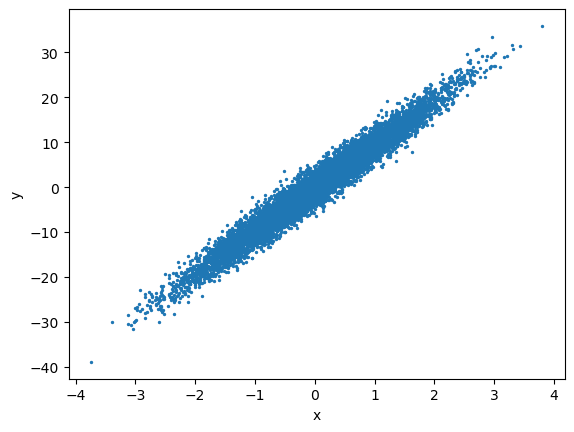

In [18]:
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, noise=2, n_samples=10000,random_state=0)
import matplotlib.pyplot as plt
plt.scatter(x,y,s=2)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [58]:
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(n_estimators=100)
reg.fit(x, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
reg.score(x, y)

0.992665

In [60]:
from sklearn.ensemble import GradientBoostingRegressor
reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1)
reg.fit(x,y)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [61]:
reg.score(x, y)

0.9998648090606818